# 라이브러리 불러오기

In [1]:
#드라이브마운트
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
#기본 라이브러리
import pandas as pd
import numpy as np

# 코랩 폰트 코드

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

# 회사현황 지표

## 매출

In [ ]:
#a 마트
a= pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/A지점.csv")

In [ ]:
#b 마트
b= pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/B지점.csv")
#c 마트
c= pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/C지점.csv")
#d 마트
d= pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/D지점.csv")

In [ ]:
# 매장 총 매출
market =pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/마켓프로젝트/마켓 CSV파일모음/전체매장데이터.csv")

### 총 매출



In [ ]:
market['구매금액'].unique()

array([  3829,   4977,   7083, ...,  27874, -54752,  -5247])

구매금액의 경우 반품 금액은 -로 표시되어 있음 따라서 구매했다가 반품을 한 경우에는 + - 제로가 되어서 구매금액 자체에 대해 특별한 이상치는 없어서 진행 가능

In [ ]:
market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294645 entries, 0 to 294644
Data columns (total 16 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   공급일자    294645 non-null  object 
 1   회원번호    294645 non-null  int64  
 2   조합원상태   294645 non-null  object 
 3   물품대분류   294645 non-null  object 
 4   물품중분류   294645 non-null  object 
 5   물품소분류   294645 non-null  object 
 6   물품명     294645 non-null  object 
 7   구매수량    294645 non-null  float64
 8   구매금액    294645 non-null  int64  
 9   구매매장    294645 non-null  object 
 10  구매시각    294645 non-null  object 
 11  반품일자    4960 non-null    object 
 12  구매월     294645 non-null  int64  
 13  구매일     294645 non-null  int64  
 14  구매시간대   294645 non-null  int64  
 15  반품소요기간  294645 non-null  int64  
dtypes: float64(1), int64(6), object(9)
memory usage: 36.0+ MB


In [ ]:
market['구매금액'].describe()

count    2.946450e+05
mean     1.104772e+04
std      1.772502e+04
min     -6.662160e+05
25%      4.020000e+03
50%      7.370000e+03
75%      1.320900e+04
max      2.890766e+06
Name: 구매금액, dtype: float64

In [ ]:
#총 매출
total_sales = market['구매금액'].sum()

In [ ]:
print("총 매출",total_sales)

총 매출 3255156423


에코빅 마켓의 2023-01-06 ~ 2023-11-04의 총 매출액은 32.55억원(3,225,156,423)이다.

### 월별 매출 변화 추세

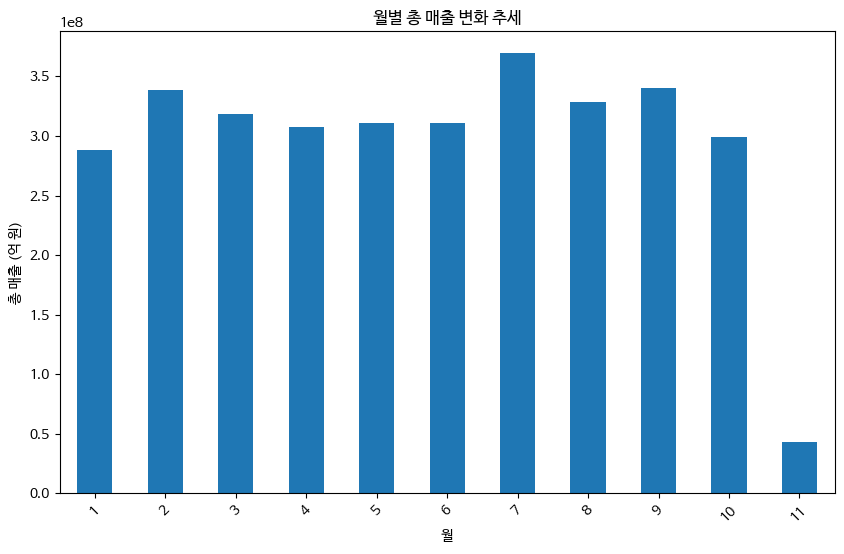

In [ ]:
import matplotlib.pyplot as plt
#월별 총 매출 계산
monthly_sales = market.groupby('구매월')['구매금액'].sum()

#시각화
plt.figure(figsize=(10,6))
monthly_sales.plot(kind='bar')
plt.title('월별 총 매출 변화 추세')
plt.xlabel('월')
plt.ylabel('총 매출 (억 원)')
plt.xticks(rotation=45)
plt.show()

### 11월 데이터 제외한 월 매출 변화 추세

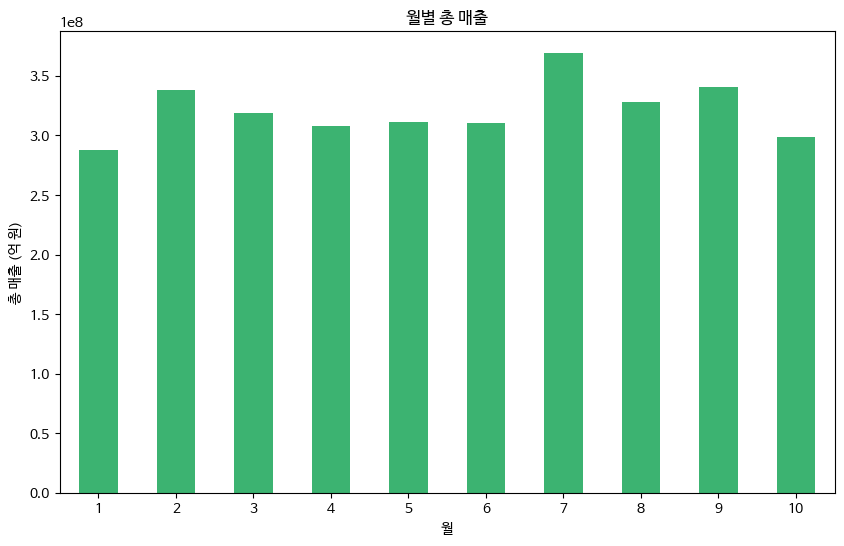

In [ ]:
import matplotlib.pyplot as plt

# 11월 데이터 제외
monthly_sales_excluding_november = monthly_sales.drop(11, errors='ignore')

# 월별 총 매출 그래프 생성
plt.figure(figsize=(10, 6))  # 그래프의 크기 지정
monthly_sales_excluding_november.plot(kind='bar', color='mediumseagreen')  # 막대그래프를 그림

plt.title('월별 총 매출')
plt.xlabel('월')
plt.ylabel('총 매출 (억 원)')
plt.xticks(rotation=0)  # x축 레이블 회전 설정

plt.show()


* 월 평균 매출은 2.95억원이다
* 7월에는 3.69원으로 매출 최고치를 찍었다.
* 1월에는 2.97억원 매출 최저치를 찍었따.
* 11월에 급격하게 매출이 감소했지만 이는 데이터 집계가 11/4까지만 이루어졌기 때문이다.



In [ ]:
monthly_sales.describe()

count    1.100000e+01
mean     2.959233e+08
std      8.673902e+07
min      4.335072e+07
25%      3.033359e+08
50%      3.109677e+08
75%      3.334519e+08
max      3.694032e+08
Name: 구매금액, dtype: float64

In [ ]:
#월 별 총 매출 변화 추세
# 세자리 단위로 쉼표를 넣어서 출력하기 위해 문자열 포맷팅 사용
formatted_monthly_sales = {month: "{:,.0f}".format(sales) for month,sales in monthly_sales.items()}

In [ ]:
formatted_monthly_sales

{1: '287,836,736',
 2: '338,457,033',
 3: '318,653,505',
 4: '307,901,459',
 5: '310,967,698',
 6: '310,750,620',
 7: '369,403,250',
 8: '328,446,742',
 9: '340,618,336',
 10: '298,770,327',
 11: '43,350,717'}

### 지점 별 매출

In [ ]:
# 각 지점별 데이터 프레임 예시: a, b, c, d
# 이 부분은 실제 데이터 프레임으로 교체해야 합니다.

# 지점별 총 매출 계산
total_sales_a = a['구매금액'].sum()
total_sales_b = b['구매금액'].sum()
total_sales_c = c['구매금액'].sum()
total_sales_d = d['구매금액'].sum()

# 결과 출력
print("지점 A의 총 매출: {:,.0f}원".format(total_sales_a))
print("지점 B의 총 매출: {:,.0f}원".format(total_sales_b))
print("지점 C의 총 매출: {:,.0f}원".format(total_sales_c))
print("지점 D의 총 매출: {:,.0f}원".format(total_sales_d))


지점 A의 총 매출: 583,534,688원
지점 B의 총 매출: 714,766,800원
지점 C의 총 매출: 1,330,038,919원
지점 D의 총 매출: 626,816,016원


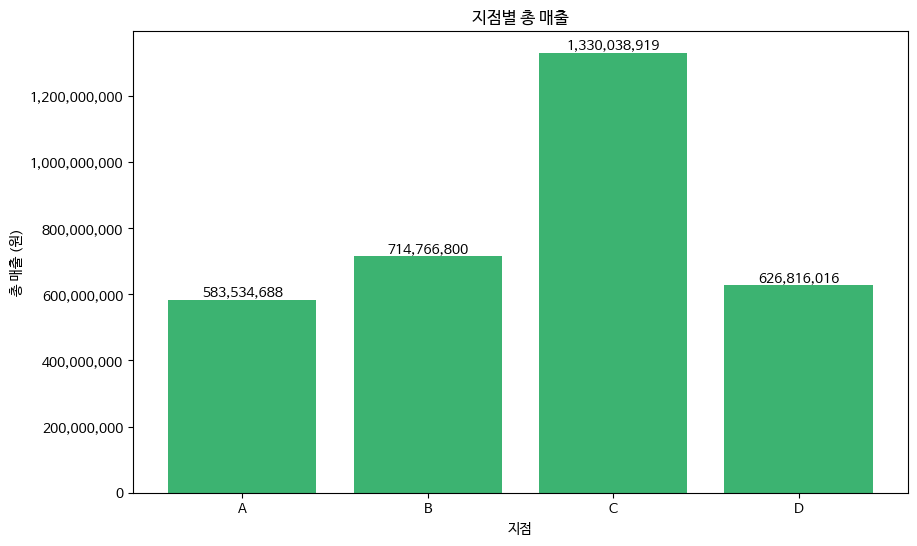

In [ ]:
import matplotlib.pyplot as plt

# 지점별 총 매출 데이터
total_sales = [total_sales_a, total_sales_b, total_sales_c, total_sales_d]
branches = ['A', 'B', 'C', 'D']  # 지점 명칭

# 막대그래프 생성
plt.figure(figsize=(10, 6))  # 그래프의 크기 지정
bars = plt.bar(branches, total_sales, color='mediumseagreen')  # 막대그래프를 그림

# 그래프 타이틀 및 축 레이블 설정
plt.title('지점별 총 매출')
plt.xlabel('지점')
plt.ylabel('총 매출 (원)')

# y축의 값을 세자리마다 쉼표로 구분하여 표시
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

# 각 막대 위에 숫자 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, "{:,.0f}".format(yval), ha='center', va='bottom')

plt.show()


* C지점 매출이 약 13.3억원으로 유일하게 십억 대 매출을 달성한 지점이다.

* A지점의 총 매출: 583,534,688원
* B지점의 총 매출: 626,816,016원
* D지점의 총 매출:714,766,800원


### 월 별 매출 집계 기준 새롭게 설정(당월 6일 ~ 다음날 4일) 폐지 !!!


* 월 별 매출을 단순히 월로 잘라서 하니까 11월만 4일치 데이터 밖에없음
* 1/6 ~ 11/4까지 잘라서 준 이유는 이 회사에서 월 매출을 집계하는 기준이 당 월 6일부터 다음달 4일까지 총 30일인 것 같음
* 혹시나를 대비해 회계 기준 월 컬럼을 만들고자 함

In [ ]:
market['공급일자'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 294645 entries, 0 to 294644
Series name: 공급일자
Non-Null Count   Dtype 
--------------   ----- 
294645 non-null  object
dtypes: object(1)
memory usage: 2.2+ MB


In [ ]:
# '공급일자' 열을 날짜 타입으로 변환
market['공급일자'] = pd.to_datetime(market['공급일자'])

# 회계 월 결정을 위한 함수 정의
def determine_fiscal_month(supply_date):
    # 6일 이후면 같은 월을, 5일 이하면 이전 월을 회계 월로 함
    if supply_date.day > 5:
        return supply_date.month
    else:
        return supply_date.month - 1 if supply_date.month > 1 else 12

# '회계월' 열 추가
market['회계월'] = market['공급일자'].apply(determine_fiscal_month)

# 회계 월별 매출 계산
monthly_sales = market.groupby('회계월')['구매금액'].sum()

monthly_sales
